<a href="https://colab.research.google.com/github/Suthirtha2004/ml-from-scratch/blob/main/Feature_Scaling_and_Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Load the dataset

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML_From_Scratch/01_Regression/house_features_dataset.csv")
print(df.head())

   Size(sqft)  Bedrooms  Floors  Age(years)  Price($1k)
0        1200         2       1          15         220
1        2400         4       2           5         450
2         850         1       1          30         140
3        3100         5       2           2         610
4        1750         3       1          12         310


In [3]:
# Load the training and output parameters
data = np.loadtxt("/content/drive/MyDrive/Colab Notebooks/ML_From_Scratch/01_Regression/house_features_dataset.csv",delimiter=',',skiprows=1)
x_train = data[:,:4]
y_train = data[:,4]

print(x_train)
print(y_train)

[[1.20e+03 2.00e+00 1.00e+00 1.50e+01]
 [2.40e+03 4.00e+00 2.00e+00 5.00e+00]
 [8.50e+02 1.00e+00 1.00e+00 3.00e+01]
 [3.10e+03 5.00e+00 2.00e+00 2.00e+00]
 [1.75e+03 3.00e+00 1.00e+00 1.20e+01]
 [2.10e+03 3.00e+00 2.00e+00 8.00e+00]
 [9.50e+02 2.00e+00 1.00e+00 2.50e+01]
 [4.00e+03 5.00e+00 3.00e+00 1.00e+00]
 [1.50e+03 3.00e+00 1.00e+00 1.80e+01]
 [2.80e+03 4.00e+00 2.00e+00 4.00e+00]
 [1.10e+03 2.00e+00 1.00e+00 2.00e+01]
 [3.50e+03 4.00e+00 2.00e+00 3.00e+00]
 [1.90e+03 3.00e+00 2.00e+00 1.00e+01]
 [2.25e+03 4.00e+00 1.00e+00 6.00e+00]
 [8.00e+02 1.00e+00 1.00e+00 3.50e+01]
 [1.60e+03 3.00e+00 1.00e+00 1.40e+01]
 [2.90e+03 4.00e+00 2.00e+00 7.00e+00]
 [1.35e+03 2.00e+00 1.00e+00 2.20e+01]
 [3.80e+03 5.00e+00 3.00e+00 2.00e+00]
 [2.00e+03 3.00e+00 2.00e+00 9.00e+00]]
[220. 450. 140. 610. 310. 390. 165. 850. 260. 520. 190. 710. 340. 410.
 125. 280. 540. 210. 800. 360.]


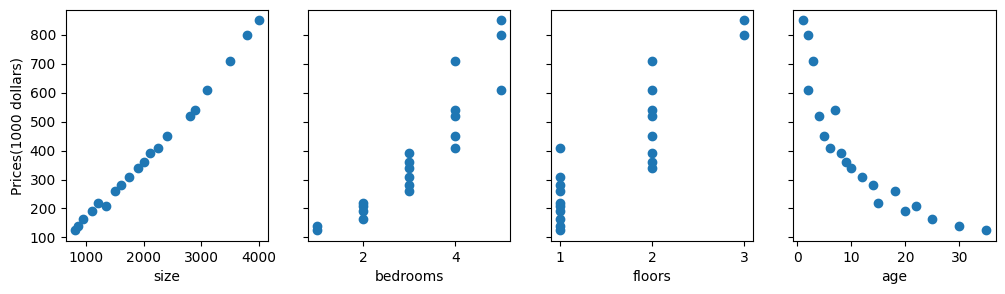

In [4]:
# Plot the features vs Target Price
x_features = ['size','bedrooms','floors','age']
fig,ax = plt.subplots(1,4,figsize =(12,3),sharey=True)
for i in range (len(ax)):
  ax[i].scatter(x_train[:,i],y_train)
  ax[i].set_xlabel(x_features[i])

ax[0].set_ylabel("Prices(1000 dollars)")
plt.show()


Feature scaling is a data preprocessing technique used to bring all numerical features in a dataset onto a similar scale or range.

Z-Score Normalisation (Standardisation): Scales data to have a mean of 0 and a standard deviation of 1; best for handling outliers.

Min-Max Scaling (Normalisation): Rescales data strictly between 0 and 1 based on minimum and maximum values; best for neural networks.

Mean Normalisation: Rescales data between -1 and 1 by centering the data around its mean; best when zero-centered bounded ranges are needed.

Max Absolute Scaling: Scales data between -1 and 1 by dividing by the maximum absolute value; best for sparse datasets (mostly zeros) because it preserves zero values.

In [5]:
# Z Score Normalization

def normalize_zscore(x):

  """
    Computes normalized X , zscore by column

    Arguments:
    x(ndarray(m,n)) : m examples with n features

    Returns :
    x_norm(ndarray(m,n)) : input normalized by column
    mu(ndarray(n,)) : mean of each feature
    sigma(ndaaray(n,0)) : standard deviation of each column/feature
  """
  mu = np.mean(x,axis = 0)
  sigma = np.std(x,axis = 0)
  x_norm = (x-mu)/sigma
  return (mu,sigma,x_norm)

In [6]:
# Normalization of features

x_mean , x_sigma , x_norm = normalize_zscore(x_train)
print(f"x_mean = {x_mean} , \nx_sigma = {x_sigma}")
print(f"Peak to Peak range by column Original X: {np.ptp(x_train)}")
print(f"Peak to Peak range by column Original X: {np.ptp(x_norm)}")


x_mean = [2.0925e+03 3.1500e+00 1.6000e+00 1.2400e+01] , 
x_sigma = [9.59983724e+02 1.19478031e+00 6.63324958e-01 9.58331884e+00]
Peak to Peak range by column Original X: 3999.0
Peak to Peak range by column Original X: 4.157758429811707


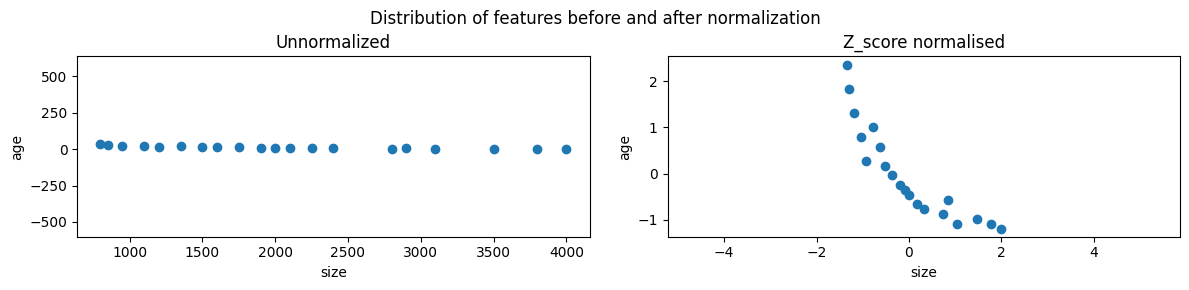

In [8]:
# Distribution of Normalised and Original Features

fig,ax = plt.subplots(1,2,figsize=(12,3))
ax[0].scatter(x_train[:,0],x_train[:,3])
ax[0].set_xlabel(x_features[0])
ax[0].set_ylabel(x_features[3])
ax[0].set_title("Unnormalized")
ax[0].axis('equal')

ax[1].scatter(x_norm[:,0],x_norm[:,3])
ax[1].set_xlabel(x_features[0])
ax[1].set_ylabel(x_features[3])
ax[1].set_title("Z_score normalised")
ax[1].axis('equal')
plt.tight_layout(rect=[0,0.03,1,0.95])
fig.suptitle("Distribution of features before and after normalization")
plt.show()
